# Section 2: LWP  —  3D vs 1D

**2.1** Domain-mean LWP timeseries: ensemble mean ± spread for each RT type  
**2.2** 3D − 1D difference: time-integral over cloudy period (absolute and normalised)

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from cass_analysis import (
    RunSet,
    load_stats_ensemble,
    load_xy_ensemble,
    compute_lwp_diff, compute_lwp_diff_from_stats,
    lwp_integral, lwp_normalized_diff, _to_plottime,
    plot_lwp_comparison, plot_lwp_diff_timeseries,
    RT_STYLE, RT_LABEL,
)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCRATCH = "/pscratch/sd/m/mpowell/CASS_LES"
EXPT    = "debug/no_aerosols"      # change to switch experiment
N_REPS  = 1                 # 1 for debug, 4 for production
# ─────────────────────────────────────────────────────────────────────────────

rs = RunSet(EXPT, f"{SCRATCH}/{EXPT}", n_reps=N_REPS)
print(rs)

RunSet('debug/no_aerosols', root=/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols)
  2stream: 1 rep(s)
  raytracer: 1 rep(s)


In [2]:
# Load xy (qlqi_path is all we strictly need for LWP; load others for cloud stats)
xy_vars = ["qlqi_path", "qlqi_base", "qlqi_top"]

ds_2s_mean, ds_2s_std = load_xy_ensemble(rs.dirs["2stream"],   variables=xy_vars)
ds_rt_mean, ds_rt_std = load_xy_ensemble(rs.dirs["raytracer"], variables=xy_vars)

# Also load stats for scalar cloud fraction (qlqi_cover) and domain-mean timing
s2s_mean, _ = load_stats_ensemble(rs.dirs["2stream"])
srt_mean, _ = load_stats_ensemble(rs.dirs["raytracer"])

print("XY datasets loaded.")
print(f"  2stream time range:   {ds_2s_mean.time.values[0]} → {ds_2s_mean.time.values[-1]}")
print(f"  raytracer time range: {ds_rt_mean.time.values[0]} → {ds_rt_mean.time.values[-1]}")

XY datasets loaded.
  2stream time range:   2005-07-24T05:30:00.000000000 → 2005-07-24T19:23:00.000000000
  raytracer time range: 2005-07-24T05:30:00.000000000 → 2005-07-24T17:32:00.000000000


## 2.1  LWP timeseries

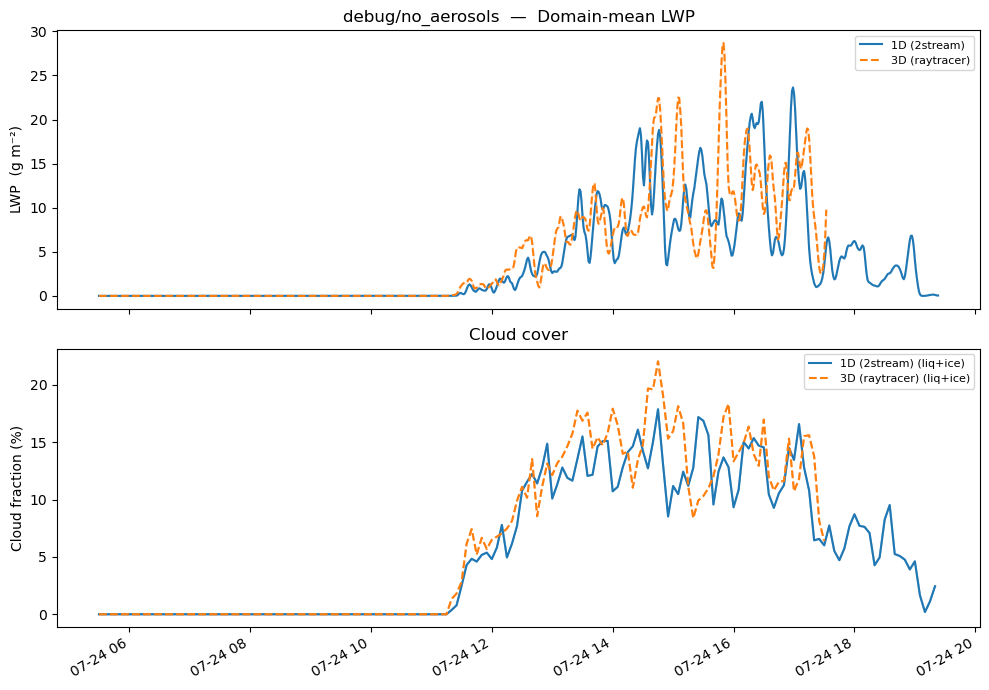

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ── Panel 1: LWP mean ± spread ───────────────────────────────────────────────
plot_lwp_comparison(axes[0], ds_2s_mean, ds_2s_std, ds_rt_mean, ds_rt_std)
axes[0].set_title(f"{rs.name}  —  Domain-mean LWP")

# ── Panel 2: Cloud cover ─────────────────────────────────────────────────────
ax = axes[1]
for rt, sm in [("2stream", s2s_mean), ("raytracer", srt_mean)]:
    sty   = RT_STYLE[rt]
    t_num = _to_plottime(sm["t_local"])         # would be nice under the hood
    ax.plot(t_num, sm["qlqi_cover"] * 100,
            label=f"{RT_LABEL[rt]} (liq+ice)", **sty)
    ax.plot(t_num, sm["ql_cover"] * 100,
            color=sty["color"], ls=sty["ls"], alpha=0.4)

ax.set_ylabel("Cloud fraction (%)")
ax.set_title("Cloud cover")
ax.legend(fontsize=8)
ax.xaxis_date()                                  
ax.figure.autofmt_xdate()

plt.tight_layout()
plt.show()

In [4]:
# Summary statistics
print("LWP summary (domain mean, g m⁻²)")
for rt, ds_m in [("2stream", ds_2s_mean), ("raytracer", ds_rt_mean)]:
    lwp = (ds_m["qlqi_path"].mean(["x", "y"]) * 1e3).compute()
    cloudy = lwp > 0.01
    print(f"  {rt:<12}  max={float(lwp.max()):.2f}  "
          f"mean(cloudy)={float(lwp.where(cloudy).mean()):.2f}")

LWP summary (domain mean, g m⁻²)
  2stream       max=23.64  mean(cloudy)=6.69
  raytracer     max=28.68  mean(cloudy)=8.72


## 2.2  3D − 1D differences

The **absolute** difference (g m⁻²) integrated over the cloudy period gives a summary
scalar in g m⁻² h.  
The **normalised** difference (3D−1D)/1D×100% shows the relative change.

In [5]:
diff_da = compute_lwp_diff(ds_2s_mean, ds_rt_mean).compute()

# Detect cloud onset: first time when either RT shows LWP > threshold
lwp_1d = (ds_2s_mean["qlqi_path"].mean(["x", "y"]) * 1e3).compute()
lwp_3d = (ds_rt_mean["qlqi_path"].mean(["x", "y"]) * 1e3).compute()
nt = min(diff_da.sizes["time"], lwp_1d.sizes["time"])
cloudy_mask = ((lwp_1d[:nt] > 0.1) | (lwp_3d[:nt] > 0.1)).values

# Timestep in seconds (from time coordinate)
t = diff_da.time.values
dt_s = float(pd.Timedelta(t[1] - t[0]).total_seconds()) if len(t) > 1 else 60.0

integral_val = lwp_integral(diff_da.values, dt_s, cloudy_mask=cloudy_mask)
print(f"∫(3D−1D) LWP dt = {integral_val:+.2f} g m⁻² h  (cloudy period)")

# Normalised difference
norm_diff = lwp_normalized_diff(diff_da.values[:nt], lwp_1d.values[:nt]) * 100.0  # %

∫(3D−1D) LWP dt = +6.72 g m⁻² h  (cloudy period)


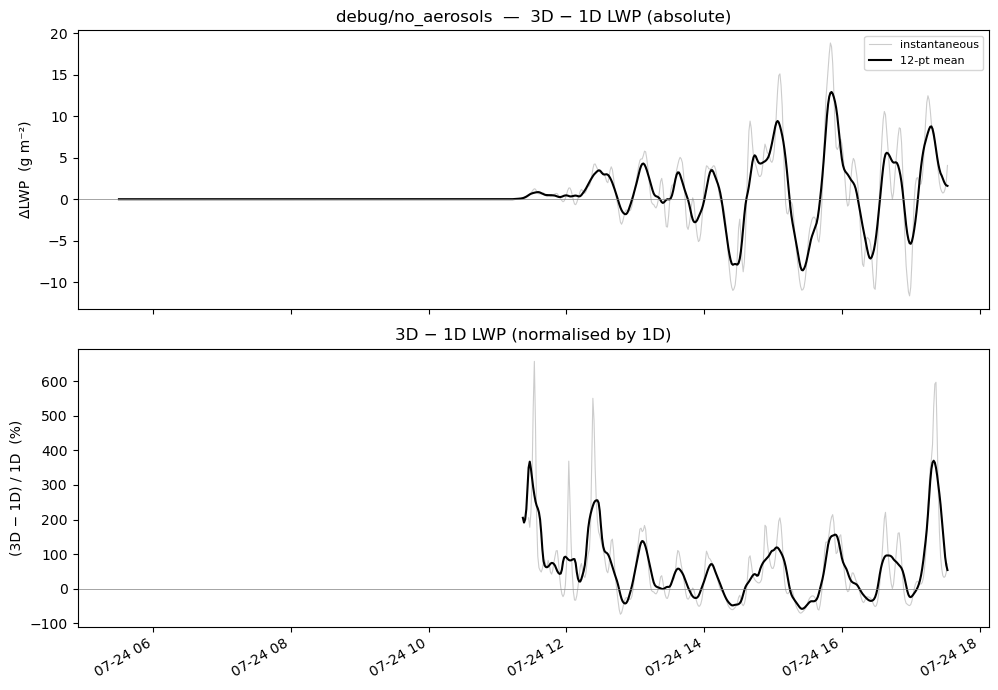

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ── Panel 1: Absolute difference ─────────────────────────────────────────────
plot_lwp_diff_timeseries(axes[0], diff_da, integral_val=integral_val)
axes[0].set_title(f"{rs.name}  —  3D − 1D LWP (absolute)")

# ── Panel 2: Normalised difference ───────────────────────────────────────────
ax = axes[1]
norm_s = pd.Series(norm_diff).rolling(12, center=True, min_periods=1).mean().values
ax.plot(diff_da.time.values[:nt], norm_diff, color="gray", alpha=0.4, lw=0.8)
ax.plot(diff_da.time.values[:nt], norm_s,    color="k",    lw=1.5)
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("(3D − 1D) / 1D  (%)")
ax.set_title("3D − 1D LWP (normalised by 1D)")
ax.figure.autofmt_xdate()

plt.tight_layout()
plt.show()